In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix
)

import joblib

In [5]:
df = pd.read_csv("D:\shana\DATASET\crop_disease_prediction_dataset.csv")

df.head()

<>:1: SyntaxWarning: invalid escape sequence '\s'
<>:1: SyntaxWarning: invalid escape sequence '\s'
C:\Users\Anand\AppData\Local\Temp\ipykernel_15984\3728935587.py:1: SyntaxWarning: invalid escape sequence '\s'
  df = pd.read_csv("D:\shana\DATASET\crop_disease_prediction_dataset.csv")


,Crop,Temperature_C,Humidity_Percent,Rainfall_mm,Soil_Moisture_Percent,Soil_pH,Nitrogen_mg_kg,Phosphorus_mg_kg,Potassium_mg_kg,Leaf_Color,Leaf_Spot,Leaf_Wilting,Leaf_Yellowing,Disease
0,Tomato,32.8,55,6.7,38,7.0,42,85,69,Green,No,No,No,Healthy
1,Tomato,22.4,72,18.1,50,7.1,127,38,72,Dark Green,No,No,No,Healthy
2,Tomato,32.0,61,8.3,52,7.9,106,23,26,Green,Yes,No,No,Early Blight
3,Maize,34.1,86,13.8,40,7.9,116,20,85,Pale Green,No,Yes,Yes,Common Rust
4,Tomato,33.5,45,25.7,37,6.1,136,91,61,Brown,No,No,Yes,Early Blight


In [6]:
print("Number of Rows:", df.shape[0])
print("Number of Columns:", df.shape[1])

Number of Rows: 1000
Number of Columns: 14


In [7]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 14 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   Crop                   1000 non-null   object 
 1   Temperature_C          1000 non-null   float64
 2   Humidity_Percent       1000 non-null   int64  
 3   Rainfall_mm            1000 non-null   float64
 4   Soil_Moisture_Percent  1000 non-null   int64  
 5   Soil_pH                1000 non-null   float64
 6   Nitrogen_mg_kg         1000 non-null   int64  
 7   Phosphorus_mg_kg       1000 non-null   int64  
 8   Potassium_mg_kg        1000 non-null   int64  
 9   Leaf_Color             1000 non-null   object 
 10  Leaf_Spot              1000 non-null   object 
 11  Leaf_Wilting           1000 non-null   object 
 12  Leaf_Yellowing         1000 non-null   object 
 13  Disease                1000 non-null   object 
dtypes: float64(3), int64(5), object(6)
memory usage: 109.5+ K

In [8]:
df.describe()

,Temperature_C,Humidity_Percent,Rainfall_mm,Soil_Moisture_Percent,Soil_pH,Nitrogen_mg_kg,Phosphorus_mg_kg,Potassium_mg_kg
count,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000
mean,27.974500,66.901000,15.127600,57.293000,6.503100,86.512000,55.110000,68.464000
std,5.730326,16.092675,8.739908,18.745307,0.841599,38.832974,26.316962,30.682864
min,18.000000,40.000000,0.000000,25.000000,5.000000,20.000000,10.000000,15.000000
25%,22.900000,52.000000,7.500000,41.000000,5.800000,51.750000,32.000000,41.000000
50%,27.850000,66.000000,14.900000,56.000000,6.500000,88.000000,55.000000,70.000000
75%,32.800000,81.000000,22.900000,74.000000,7.200000,122.000000,78.000000,95.000000
max,38.000000,95.000000,30.000000,90.000000,8.000000,150.000000,100.000000,120.000000


In [9]:
df.isnull().sum()

Crop                     0
Temperature_C            0
Humidity_Percent         0
Rainfall_mm              0
Soil_Moisture_Percent    0
Soil_pH                  0
Nitrogen_mg_kg           0
Phosphorus_mg_kg         0
Potassium_mg_kg          0
Leaf_Color               0
Leaf_Spot                0
Leaf_Wilting             0
Leaf_Yellowing           0
Disease                  0
dtype: int64

In [10]:
print("Duplicate Rows:", df.duplicated().sum())

Duplicate Rows: 0


In [11]:
df = df.drop_duplicates()

print("Dataset Shape:", df.shape)

Dataset Shape: (1000, 14)


In [12]:
df = df.drop_duplicates()

print("Dataset Shape:", df.shape)

Dataset Shape: (1000, 14)


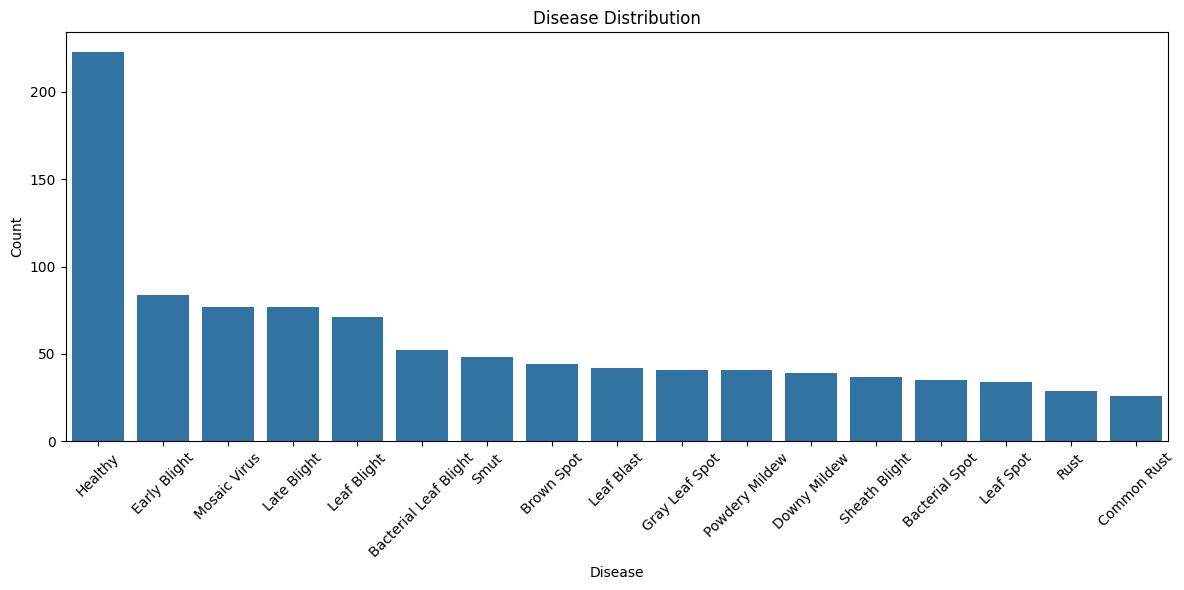

In [13]:
plt.figure(figsize=(12, 6))

sns.countplot(
    data=df,
    x="Disease",
    order=df["Disease"].value_counts().index
)

plt.title("Disease Distribution")
plt.xlabel("Disease")
plt.ylabel("Count")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

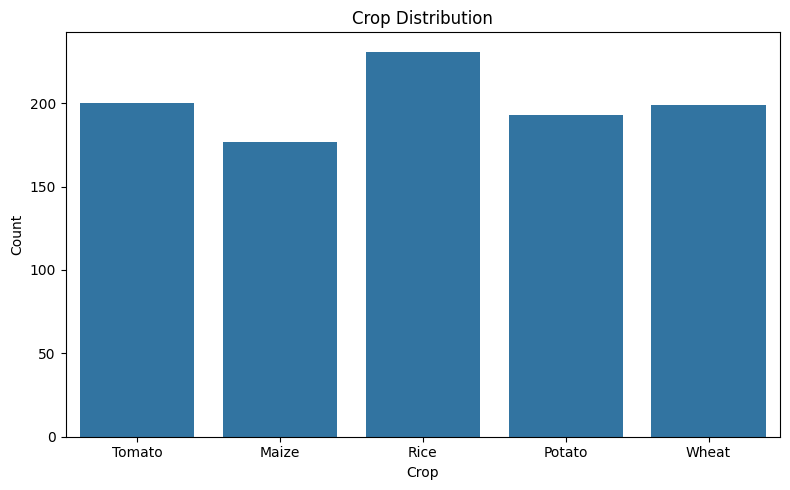

In [14]:
plt.figure(figsize=(8, 5))

sns.countplot(
    data=df,
    x="Crop"
)

plt.title("Crop Distribution")
plt.xlabel("Crop")
plt.ylabel("Count")

plt.tight_layout()
plt.show()

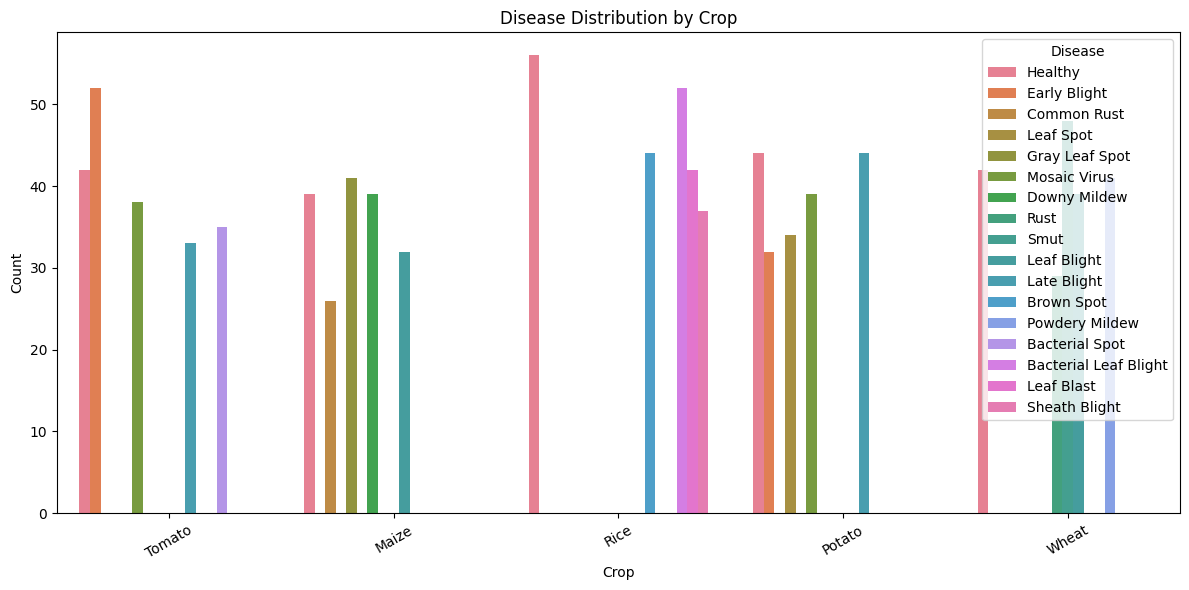

In [15]:
plt.figure(figsize=(12, 6))

sns.countplot(
    data=df,
    x="Crop",
    hue="Disease"
)

plt.title("Disease Distribution by Crop")
plt.xlabel("Crop")
plt.ylabel("Count")
plt.xticks(rotation=30)

plt.tight_layout()
plt.show()

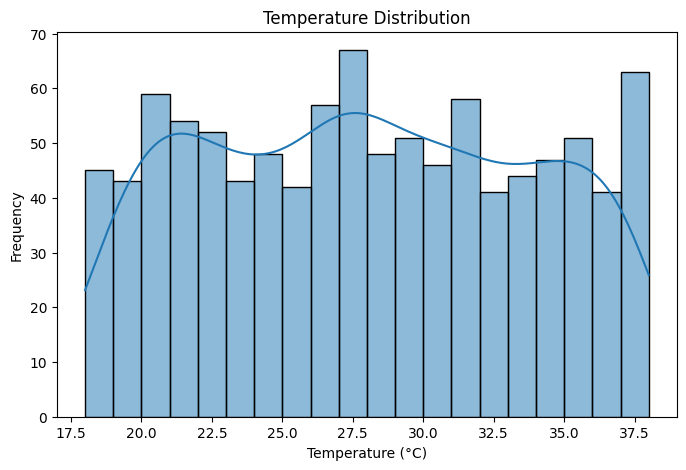

In [16]:
plt.figure(figsize=(8, 5))

sns.histplot(
    data=df,
    x="Temperature_C",
    bins=20,
    kde=True
)

plt.title("Temperature Distribution")
plt.xlabel("Temperature (°C)")
plt.ylabel("Frequency")

plt.show()

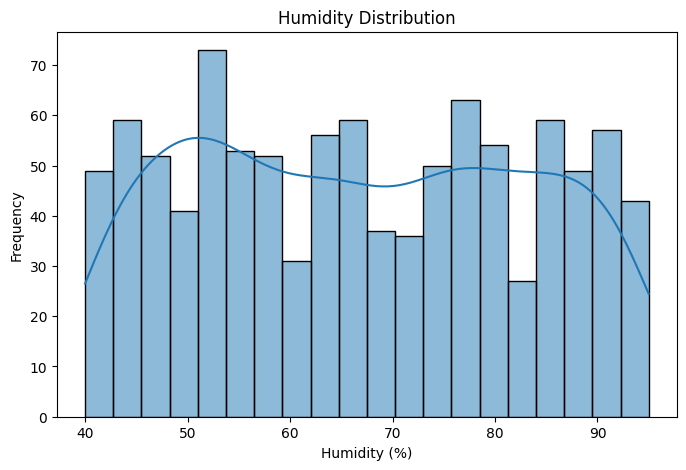

In [17]:
plt.figure(figsize=(8, 5))

sns.histplot(
    data=df,
    x="Humidity_Percent",
    bins=20,
    kde=True
)

plt.title("Humidity Distribution")
plt.xlabel("Humidity (%)")
plt.ylabel("Frequency")

plt.show()

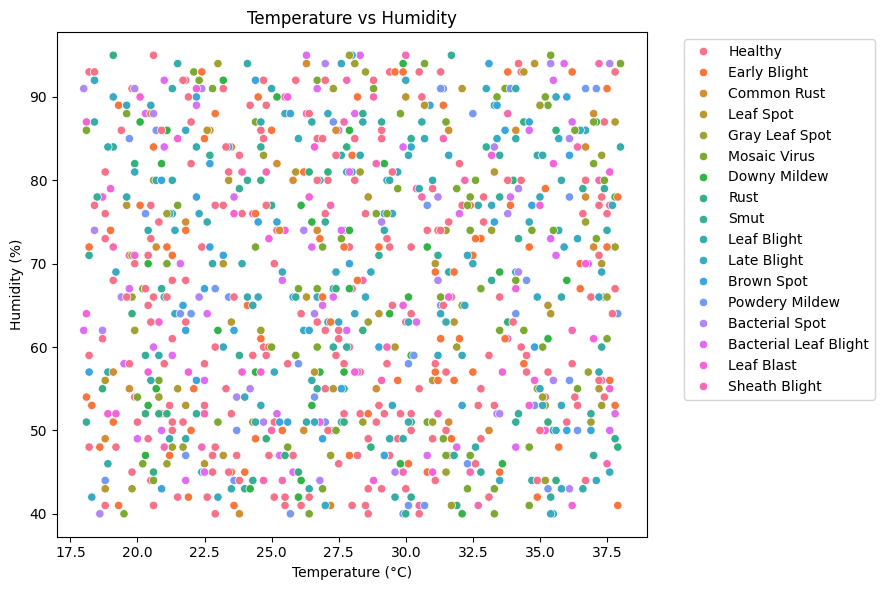

In [18]:
plt.figure(figsize=(9, 6))

sns.scatterplot(
    data=df,
    x="Temperature_C",
    y="Humidity_Percent",
    hue="Disease"
)

plt.title("Temperature vs Humidity")
plt.xlabel("Temperature (°C)")
plt.ylabel("Humidity (%)")

plt.legend(bbox_to_anchor=(1.05, 1), loc="upper left")
plt.tight_layout()
plt.show()

In [19]:
numeric_df = df.select_dtypes(include=np.number)

numeric_df.head()

,Temperature_C,Humidity_Percent,Rainfall_mm,Soil_Moisture_Percent,Soil_pH,Nitrogen_mg_kg,Phosphorus_mg_kg,Potassium_mg_kg
0,32.8,55,6.7,38,7.0,42,85,69
1,22.4,72,18.1,50,7.1,127,38,72
2,32.0,61,8.3,52,7.9,106,23,26
3,34.1,86,13.8,40,7.9,116,20,85
4,33.5,45,25.7,37,6.1,136,91,61


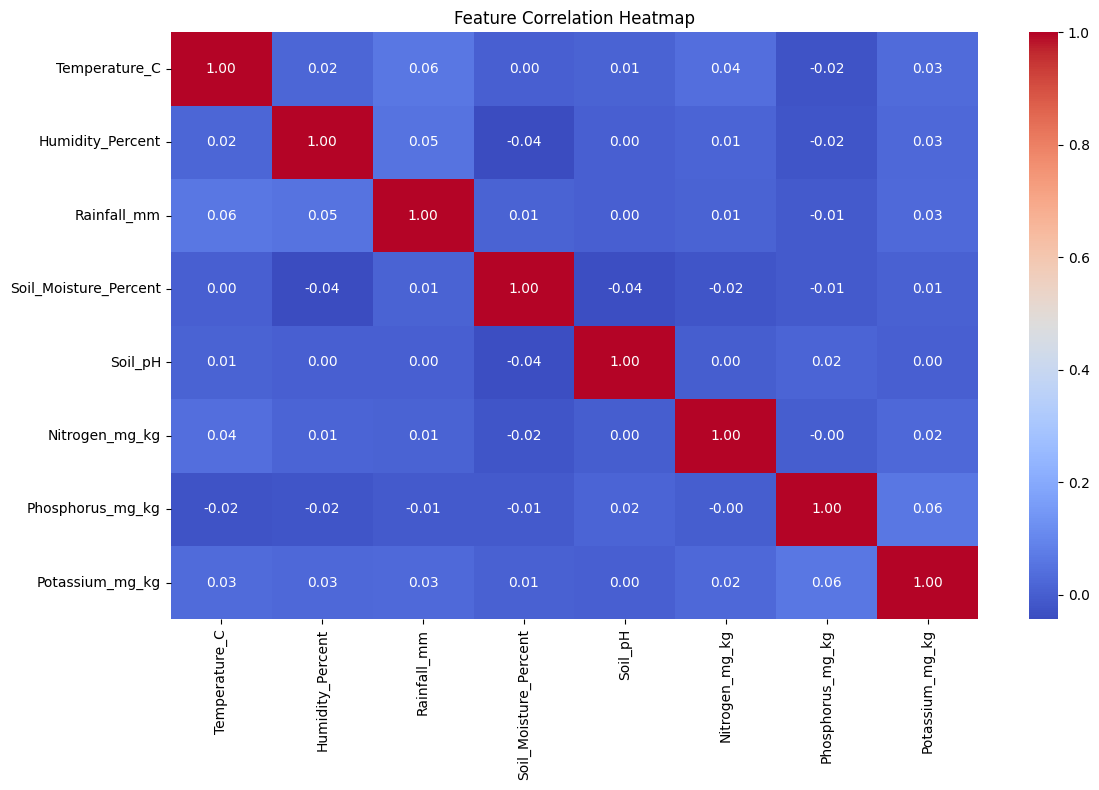

In [20]:
plt.figure(figsize=(12, 8))

sns.heatmap(
    numeric_df.corr(),
    annot=True,
    cmap="coolwarm",
    fmt=".2f"
)

plt.title("Feature Correlation Heatmap")

plt.tight_layout()
plt.show()

In [21]:
X = df.drop("Disease", axis=1)
y = df["Disease"]

In [22]:
print("Features:")
print(X.columns)

print("\nTarget:")
print(y.name)

Features:
Index(['Crop', 'Temperature_C', 'Humidity_Percent', 'Rainfall_mm',
       'Soil_Moisture_Percent', 'Soil_pH', 'Nitrogen_mg_kg',
       'Phosphorus_mg_kg', 'Potassium_mg_kg', 'Leaf_Color', 'Leaf_Spot',
       'Leaf_Wilting', 'Leaf_Yellowing'],
      dtype='object')

Target:
Disease


In [23]:
categorical_columns = X.select_dtypes(
    include=["object"]
).columns.tolist()

print("Categorical Columns:")
print(categorical_columns)

Categorical Columns:
['Crop', 'Leaf_Color', 'Leaf_Spot', 'Leaf_Wilting', 'Leaf_Yellowing']


In [24]:
encoders = {}

for column in categorical_columns:
    encoder = LabelEncoder()
    X[column] = encoder.fit_transform(X[column])
    encoders[column] = encoder

In [25]:
X.head()

,Crop,Temperature_C,Humidity_Percent,Rainfall_mm,Soil_Moisture_Percent,Soil_pH,Nitrogen_mg_kg,Phosphorus_mg_kg,Potassium_mg_kg,Leaf_Color,Leaf_Spot,Leaf_Wilting,Leaf_Yellowing
0,3,32.8,55,6.7,38,7.0,42,85,69,2,0,0,0
1,3,22.4,72,18.1,50,7.1,127,38,72,1,0,0,0
2,3,32.0,61,8.3,52,7.9,106,23,26,2,1,0,0
3,0,34.1,86,13.8,40,7.9,116,20,85,3,0,1,1
4,3,33.5,45,25.7,37,6.1,136,91,61,0,0,0,1


In [26]:
target_encoder = LabelEncoder()

y_encoded = target_encoder.fit_transform(y)

print(target_encoder.classes_)

['Bacterial Leaf Blight' 'Bacterial Spot' 'Brown Spot' 'Common Rust'
 'Downy Mildew' 'Early Blight' 'Gray Leaf Spot' 'Healthy' 'Late Blight'
 'Leaf Blast' 'Leaf Blight' 'Leaf Spot' 'Mosaic Virus' 'Powdery Mildew'
 'Rust' 'Sheath Blight' 'Smut']


In [27]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y_encoded,
    test_size=0.20,
    random_state=42,
    stratify=y_encoded
)

print("Training Data:", X_train.shape)
print("Testing Data:", X_test.shape)

Training Data: (800, 13)
Testing Data: (200, 13)


In [28]:
model = RandomForestClassifier(
    n_estimators=200,
    random_state=42
)

In [29]:
model.fit(X_train, y_train)

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",200
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=""sqrt""The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to `""sqrt""`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",'sqrt'
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is the number of samples in theleft child, and ``N_t_R`` is the number of samples in the right child.``N``, ``N_t``, ``N_t_R`` and ``N_t_L`` all refer to the weighted sum,if ``sample_weight`` is passed... versionadded:: 0.19",0.0
,"bootstrap bootstrap: bool, default=TrueWhether bootstrap samples are used when building trees. If False, thewhole dataset is used to build each tree.",True
,"oob_score oob_score: bool or callable, default=FalseWhether to use out-of-bag samples to estimate the generalization score.By default, :func:`~sklearn.metrics.accuracy_score` is used.Provide a callable with signature `metric

In [30]:
y_pred = model.predict(X_test)

In [31]:
accuracy = accuracy_score(y_test, y_pred)

print("Random Forest Accuracy:", accuracy)
print("Accuracy Percentage:", accuracy * 100)

Random Forest Accuracy: 0.39
Accuracy Percentage: 39.0


In [32]:
print(
    classification_report(
        y_test,
        y_pred,
        target_names=target_encoder.classes_
    )
)

                       precision    recall  f1-score   support

Bacterial Leaf Blight       0.25      0.30      0.27        10
       Bacterial Spot       0.00      0.00      0.00         7
           Brown Spot       0.40      0.22      0.29         9
          Common Rust       0.00      0.00      0.00         5
         Downy Mildew       0.20      0.25      0.22         8
         Early Blight       0.23      0.35      0.28        17
       Gray Leaf Spot       0.22      0.25      0.24         8
              Healthy       0.82      1.00      0.90        45
          Late Blight       0.15      0.13      0.14        15
           Leaf Blast       0.25      0.12      0.17         8
          Leaf Blight       0.27      0.29      0.28        14
            Leaf Spot       0.50      0.29      0.36         7
         Mosaic Virus       0.28      0.33      0.30        15
       Powdery Mildew       0.30      0.38      0.33         8
                 Rust       0.00      0.00      0.00  

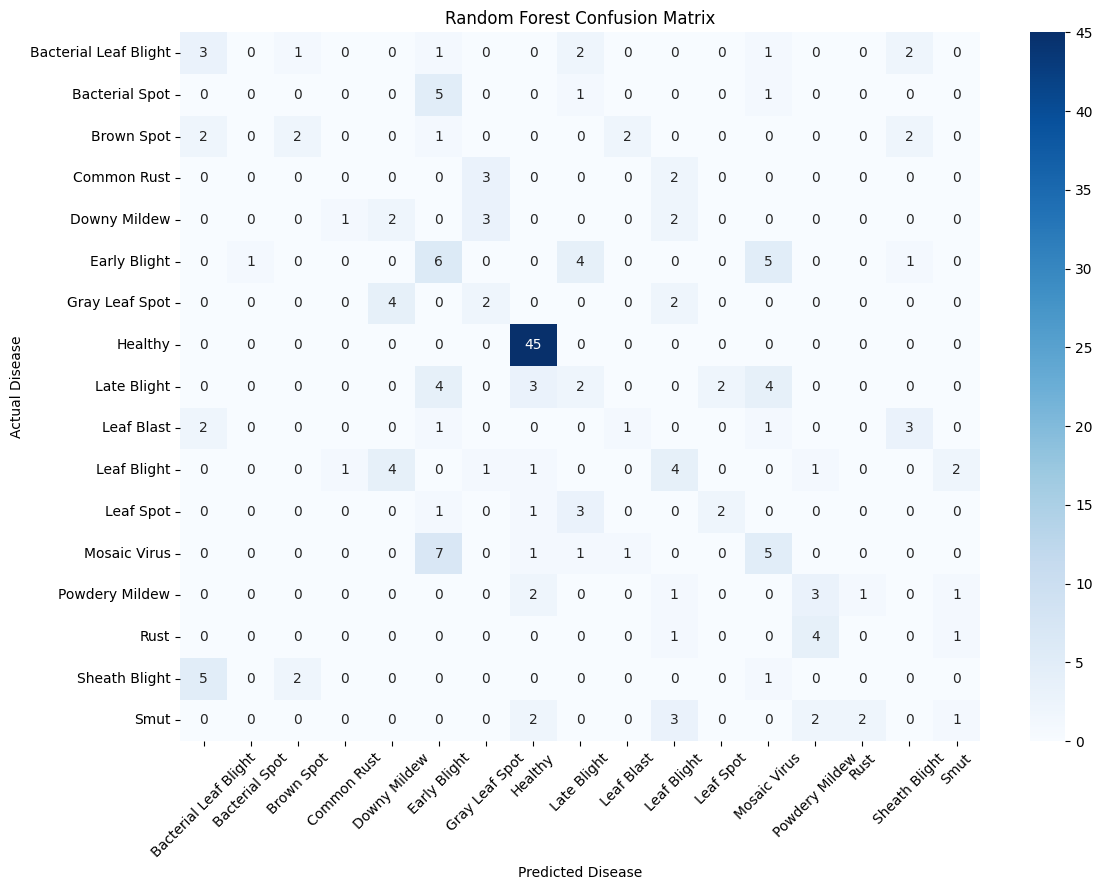

In [33]:
cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(12, 9))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=target_encoder.classes_,
    yticklabels=target_encoder.classes_
)

plt.title("Random Forest Confusion Matrix")
plt.xlabel("Predicted Disease")
plt.ylabel("Actual Disease")

plt.xticks(rotation=45)
plt.yticks(rotation=0)

plt.tight_layout()
plt.show()

In [34]:
feature_importance = pd.DataFrame({
    "Feature": X.columns,
    "Importance": model.feature_importances_
})

feature_importance = feature_importance.sort_values(
    by="Importance",
    ascending=False
)

feature_importance

,Feature,Importance
0,Crop,0.122173
9,Leaf_Color,0.088909
3,Rainfall_mm,0.087640
6,Nitrogen_mg_kg,0.084677
1,Temperature_C,0.083057
8,Potassium_mg_kg,0.082338
4,Soil_Moisture_Percent,0.082056
2,Humidity_Percent,0.080102
7,Phosphorus_mg_kg,0.078486
5,Soil_pH,0.069915


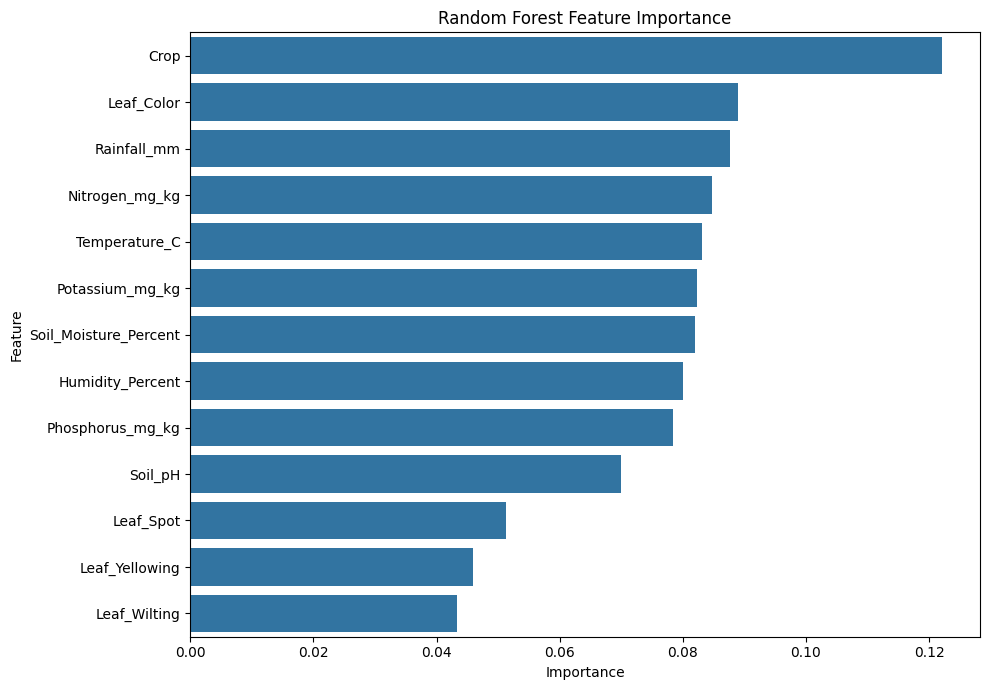

In [35]:
plt.figure(figsize=(10, 7))

sns.barplot(
    data=feature_importance,
    x="Importance",
    y="Feature"
)

plt.title("Random Forest Feature Importance")
plt.xlabel("Importance")
plt.ylabel("Feature")

plt.tight_layout()
plt.show()

In [36]:
joblib.dump(
    model,
    "crop_disease_random_forest.pkl"
)

print("Model saved successfully!")

Model saved successfully!


In [37]:
joblib.dump(
    encoders,
    "crop_feature_encoders.pkl"
)

joblib.dump(
    target_encoder,
    "crop_target_encoder.pkl"
)

print("Encoders saved successfully!")

Encoders saved successfully!


In [38]:
sample = pd.DataFrame({
    "Crop": ["Tomato"],
    "Temperature_C": [28.5],
    "Humidity_Percent": [75],
    "Rainfall_mm": [15],
    "Soil_Moisture_Percent": [60],
    "Soil_pH": [6.5],
    "Nitrogen_mg_kg": [80],
    "Phosphorus_mg_kg": [45],
    "Potassium_mg_kg": [60],
    "Leaf_Color": ["Yellow"],
    "Leaf_Spot": ["Yes"],
    "Leaf_Wilting": ["No"],
    "Leaf_Yellowing": ["Yes"]
})

sample

,Crop,Temperature_C,Humidity_Percent,Rainfall_mm,Soil_Moisture_Percent,Soil_pH,Nitrogen_mg_kg,Phosphorus_mg_kg,Potassium_mg_kg,Leaf_Color,Leaf_Spot,Leaf_Wilting,Leaf_Yellowing
0,Tomato,28.5,75,15,60,6.5,80,45,60,Yellow,Yes,No,Yes


In [39]:
for column in categorical_columns:
    sample[column] = encoders[column].transform(sample[column])

In [40]:
prediction = model.predict(sample)

predicted_disease = target_encoder.inverse_transform(prediction)

print("Predicted Disease:", predicted_disease[0])

Predicted Disease: Early Blight
